In [1]:
import geopandas as gpd
from pathlib import Path
import matplotlib.pyplot as plt
from rasterio import open as rio_open
from rasterio.mask import mask
from shapely.geometry import box


# === Standard Library ===
from pathlib import Path
import pickle

# === Scientific & Data Libraries ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm


# === Geospatial Libraries ===
import geopandas as gpd
import rasterio
import folium
from shapely.geometry import box, Point, LineString, Polygon, shape
from pyproj import Transformer
import networkx as nx
import geohexgrid as ghg
from shapely.ops import transform


# === RA2CE Project Imports ===
from ra2ce.network.network_config_data.enums.aggregate_wl_enum import AggregateWlEnum
from ra2ce.network.network_config_data.enums.source_enum import SourceEnum
from ra2ce.network.network_config_data.enums.network_type_enum import NetworkTypeEnum
from ra2ce.network.network_config_data.enums.road_type_enum import RoadTypeEnum
from ra2ce.network.network_config_data.network_config_data import (
    HazardSection,
    NetworkConfigData,
    NetworkSection,
    OriginsDestinationsSection
)
from ra2ce.network.exporters.geodataframe_network_exporter import GeoDataFrameNetworkExporter
from ra2ce.network.exporters.multi_graph_network_exporter import MultiGraphNetworkExporter
from ra2ce.network.network_wrappers.osm_network_wrapper.osm_network_wrapper import OsmNetworkWrapper
from ra2ce.ra2ce_handler import Ra2ceHandler

# === local imports ===

import os
import sys
from pathlib import Path

cwd_path = Path.cwd()   
repo_path = cwd_path.parent.parent

print('repo_path:', repo_path)

sys.path.append(str(repo_path))

from src.grid_based_accessibility_hex import read_pickle
import pickle 



repo_path: c:\repos\powerpath


In [2]:


# data_path = repo_path/'data'
data_folder_name = 'ZH_Delfland_2'
# data_path = Path(rf"N:\Projects\11209000\11209175\B. Measurements and calculations\Data\{data_folder_name}")
data_path = Path(rf'C:\repos\powerpath\raw_data\{data_folder_name}')
local_data_path = Path('C:/data')

In [4]:
directory_dictionary = {
    "root_dir": data_path,
    "static_path": data_path.joinpath("static"),
    "network_path": data_path.joinpath("static", "network"),
    "output_path": data_path.joinpath("static", "output_graph"),
    "electricity_dir": data_path.joinpath("electricity"),
    "hazard_files_dir": data_path.joinpath(f"hazard_maps_ZH_Delfland_2"),
    #Path(r'N:\Projects\11209000\11209175\B. Measurements and calculations\Data\timeseries_data\reprojected')
}

# make sure all of the directories exist
for dir_path in directory_dictionary.values():
    dir_path.mkdir(parents=True, exist_ok=True)

In [5]:
# hazard_map_path = data_path / 'static/hazard/processed/delfland_ghg200m_wgs84_processed.tif'
# List files in hazard_files_dir and select the first that doesn't contain 'blank'
hazard_files = [f for f in directory_dictionary["hazard_files_dir"].glob("*.tif") if 'blank' not in f.name]
hazard_map_path = hazard_files[0] if hazard_files else None
#Path(r'N:\Projects\11209000\11209175\B. Measurements and calculations\Data\timeseries_data\reprojected\20220610 JF  Limburgbui 200 mm 48h  voormalen 15 cm  GHG_waterschijf_1900-01-03_scale_5_wgs84.tif')
assert hazard_map_path.exists(), f"Path {hazard_map_path} does not exist"


In [6]:
ls_station_path = local_data_path.joinpath("raw", "StedinData", "Laagspanningsstations")
msls_station_path = local_data_path.joinpath("raw", "StedinData", "MiddenLaagspanningsstations")
ms_station_path = local_data_path.joinpath("raw", "StedinData", "Middenspanningsstations")

ls_lines_path = local_data_path.joinpath("raw", "StedinData", "Laagspanningsverbindingen")
ms_lines_path = local_data_path.joinpath("raw", "StedinData", "Middenspanningsverbindingen")

raw_paths = [ls_station_path,msls_station_path,ms_station_path, 
             ls_lines_path, ms_lines_path]

for path in raw_paths:
    assert path.exists(), f"Path {path} does not exist"


Hazard map CRS: EPSG:4326


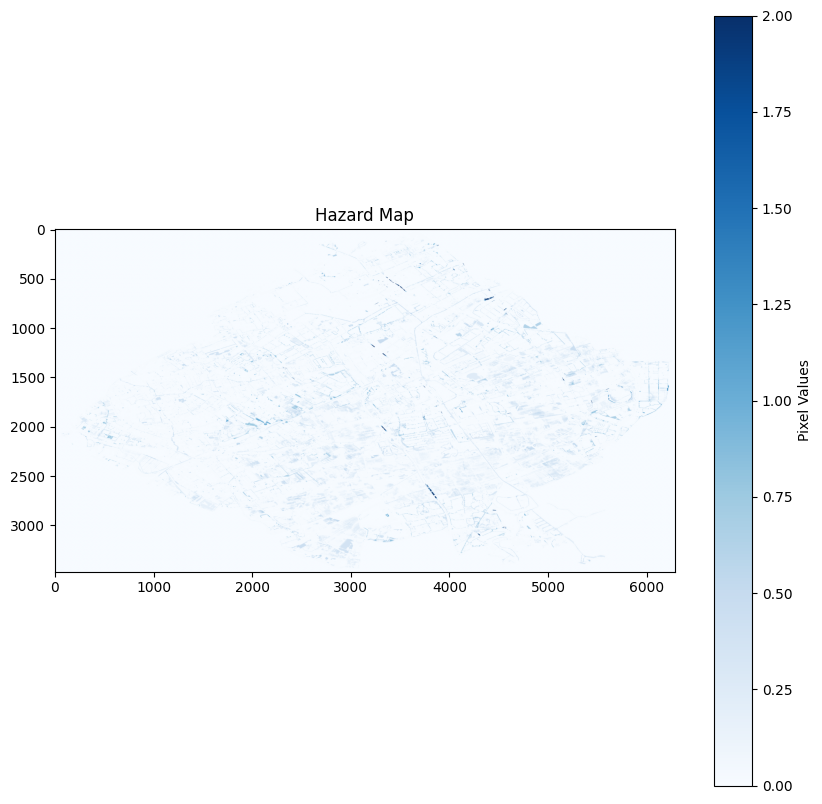

In [7]:
# find bounding box of hazard map
with rio_open(hazard_map_path) as src:
    hazard_map = src.read(1)
    hazard_transform = src.transform
    hazard_crs = src.crs
    bounding_box_haz = box(*src.bounds)
    print(f"Hazard map CRS: {hazard_crs}")
    # Reproject bounding_box to hazard_crs using GeoSeries
    # bounding_box_gs = gpd.GeoSeries([bounding_box], crs=road_network.crs)
    # bounding_box_haz_crs = bounding_box_gs.to_crs(hazard_crs).iloc[0]
    # hazard_map_clipped, hazard_transform_clipped = mask(src, [bounding_box_haz_crs], crop=True)

# plot the hazard map
plt.figure(figsize=(10, 10))
plt.imshow(hazard_map, cmap='Blues', vmin=0, vmax=2) # no data values are large negatives, so adjust the colormap 
plt.colorbar(label='Pixel Values')  
plt.title('Hazard Map')
plt.show()


In [16]:
# Buffer bounding box for the hazard by 5%
haz_xmin, haz_ymin, haz_xmax, haz_ymax = bounding_box_haz.bounds
haz_xmin -= (haz_xmax - haz_xmin) * 0.05
haz_xmax += (haz_xmax - haz_xmin) * 0.05
haz_ymin -= (haz_ymax - haz_ymin) * 0.05
haz_ymax += (haz_ymax - haz_ymin) * 0.05
bounding_box_haz_buffered = box(haz_xmin, haz_ymin, haz_xmax, haz_ymax)
print(type(bounding_box_haz_buffered))
simulation_bounding_box_gdf = gpd.GeoDataFrame(geometry=[bounding_box_haz_buffered], crs=hazard_crs)
Extent_path = data_path.joinpath('static', 'network', 'extent.shp')
Extent_path.parent.mkdir(parents=True, exist_ok=True)  # Ensure the directory exists
simulation_bounding_box_gdf.to_file(Extent_path, driver='ESRI Shapefile',)

<class 'shapely.geometry.polygon.Polygon'>


In [9]:
# load the shapefiles and clip to the bounding box
ls_stations = gpd.read_file(ls_station_path/'Laagspanningsstations.shp')
ls_stations = ls_stations.to_crs(simulation_bounding_box_gdf.crs)  # Ensure CRS matches
ls_stations = ls_stations.clip(simulation_bounding_box_gdf)
msls_stations = gpd.read_file(msls_station_path/'MiddenLaagspanningsstations.shp')
msls_stations = msls_stations.to_crs(simulation_bounding_box_gdf.crs)
msls_stations = msls_stations.clip(simulation_bounding_box_gdf)
ms_stations = gpd.read_file(ms_station_path/'Middenspanningsstations.shp')
ms_stations = ms_stations.to_crs(simulation_bounding_box_gdf.crs)  # Ensure CRS matches
ms_stations = ms_stations.clip(simulation_bounding_box_gdf)

In [10]:
# save to repo data folder
ls_stations.to_file(directory_dictionary["electricity_dir"]/f'ls_stations_{data_folder_name}.shp')
msls_stations.to_file(directory_dictionary["electricity_dir"]/f'msls_stations_{data_folder_name}.shp')
ms_stations.to_file(directory_dictionary["electricity_dir"]/f'ms_stations_{data_folder_name}.shp')

In [11]:
shapely_polygon = bounding_box_haz_buffered

In [19]:
# Extent_path = network_path.joinpath("try_study_area_larger.shp")
# Extent = gpd.read_file(Extent_path, driver='ESRI Shapefile')
# shapely_polygon = Extent.geometry.iloc[0]
# Data pre-processing
# some preliminary functions

def get_all_files(directory: str) -> list[Path]:
    p = Path(directory)
    return [file for file in p.iterdir() if file.is_file()]

def read_pickle(file_path: str):
    with open(file_path, 'rb') as file:
        data = pickle.load(file)
    return data

def read_gpkg_to_gdf(file_path: str, layer: str = None) -> gpd.GeoDataFrame:
    # Read the geopackage file into a GeoDataFrame
    gdf = gpd.read_file(file_path, layer=layer)
    return gdf


In [13]:
hazard_files = get_all_files(directory_dictionary["hazard_files_dir"])

# Open the first hazard file to get the crs
with rasterio.open(hazard_files[0]) as src:
    hazard_crs = src.crs
    print(f"Hazard CRS: {hazard_crs}")

# hazard_crs = "EPSG:4326" # for the hackathon case => "EPSG:4326" 


hazard_files = [f for f in hazard_files if not 'blank' in f.name and f.name.endswith('.tif')]

hazard_files = sorted(hazard_files, key=lambda x: x.name)

for hazard_file in hazard_files:
    print (hazard_file)



Hazard CRS: EPSG:4326
C:\repos\powerpath\raw_data\ZH_Delfland_2\hazard_maps_ZH_Delfland_2\20220610 JF  Limburgbui 200 mm 48h  voormalen 15 cm  GHG_waterschijf_1900-01-03_scale_5_wgs84.tif
C:\repos\powerpath\raw_data\ZH_Delfland_2\hazard_maps_ZH_Delfland_2\20220610 JF  Limburgbui 200 mm 48h  voormalen 15 cm  GHG_waterschijf_1900-01-04_scale_5_wgs84.tif
C:\repos\powerpath\raw_data\ZH_Delfland_2\hazard_maps_ZH_Delfland_2\20220610 JF  Limburgbui 200 mm 48h  voormalen 15 cm  GHG_waterschijf_1900-01-05_scale_5_wgs84.tif
C:\repos\powerpath\raw_data\ZH_Delfland_2\hazard_maps_ZH_Delfland_2\20220610 JF  Limburgbui 200 mm 48h  voormalen 15 cm  GHG_waterschijf_1900-01-06_scale_5_wgs84.tif
C:\repos\powerpath\raw_data\ZH_Delfland_2\hazard_maps_ZH_Delfland_2\20220610 JF  Limburgbui 200 mm 48h  voormalen 15 cm  GHG_waterschijf_1900-01-07_scale_5_wgs84.tif


In [17]:
# RA2CE last run 56 min for 5 haz maps (Delfland)
### Let us first initalize and perform the ra2ce run so we have all the data that we need
#### Cutting RoadTypeEnum.MOTORWAY,RoadTypeEnum.MOTORWAY_LINK to make analysis more realistic
_network_section = NetworkSection(
    network_type=NetworkTypeEnum.DRIVE,
    source=SourceEnum.OSM_DOWNLOAD,
    polygon=Extent_path, #it needs a path without the list!
    save_gpkg=True,
    road_types=[RoadTypeEnum.MOTORWAY, RoadTypeEnum.MOTORWAY_LINK, RoadTypeEnum.PRIMARY, RoadTypeEnum.PRIMARY_LINK,RoadTypeEnum.TRUNK, RoadTypeEnum.SECONDARY,RoadTypeEnum.SECONDARY_LINK, RoadTypeEnum.TERTIARY, RoadTypeEnum.RESIDENTIAL, RoadTypeEnum.LIVING_STREET, RoadTypeEnum.UNCLASSIFIED] 
    #attributes_to_exclude_in_simplification=['bridge', 'tunnel'],
)

# Make the NetworkConfigData
_hazard_section = HazardSection(
    hazard_map=hazard_files,
    hazard_id=None,
    hazard_field_name="waterdepth",
    aggregate_wl=AggregateWlEnum.MAX,
    hazard_crs=hazard_crs,
    overlay_segmented_network = False
)

_network_config_data = NetworkConfigData(
    root_path=directory_dictionary["root_dir"],
    static_path=directory_dictionary["static_path"],
    output_path=directory_dictionary["output_path"],
    network=_network_section,
    hazard=_hazard_section)

# Run analysis
_handler = Ra2ceHandler.from_config(_network_config_data, analysis=None)
_handler.configure()


c:\Users\peregrin\AppData\Local\miniforge3\envs\pizzacourse\Lib\site-packages\osmnx\simplification.py:513: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  merged = convert.graph_to_gdfs(G, edges=False)["geometry"].buffer(tolerance).unary_union
c:\Users\peregrin\AppData\Local\miniforge3\envs\pizzacourse\Lib\site-packages\osmnx\simplification.py:560: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = node_clusters.centroid
100%|██████████| 97219/97219 [00:00<00:00, 312779.58it/s]
2025-08-18 03:40:02 PM - [network_graph_simplificator.py:139] - root - ERROR - Could not find the simple ID belonging to complex ID (45139175, 45139712, 0); value set to None. Full error: 80500
2025-08-18 03:40:02 PM - [network_grap

In [20]:
# Create base_graph_hazard_editted, adding EV0 as initial state and EV6-9 as recovery steps 

number_of_timesteps = 10

input_graph = directory_dictionary['output_path']/'base_graph_hazard.p'
output_graph = directory_dictionary['output_path']/'base_graph_hazard_editted.p'
if not output_graph.exists():
    base_graph = read_pickle(input_graph)
    base_graph_hazard_editted = base_graph.copy()

# Add column EV0_ma and set to 0.0, also set EV6-9 to 0.0
for i in range(number_of_timesteps):
    col_name = f'EV{i}_ma'
    
    # For NetworkX graphs, we need to add attributes to each edge
    for u, v, key in base_graph_hazard_editted.edges(keys=True):
        # Check if the attribute exists on any edge, if not add it
        if col_name not in base_graph_hazard_editted[u][v][key]:
            base_graph_hazard_editted[u][v][key][col_name] = 0.0
        
        # Set EV6-9 to 0.0
        if i >= 6:
            base_graph_hazard_editted[u][v][key][col_name] = 0.0

pickle.dump(base_graph_hazard_editted, open(output_graph, 'wb'))  # Save the modified graph
    # Save the modified graph

In [30]:
# Graph printouts 
for u,v,d in base_graph_hazard_editted.edges(data=True):
    print(d.keys())
    break

dict_keys(['osmid', 'lanes', 'name', 'highway', 'maxspeed', 'oneway', 'reversed', 'length', 'rfid_c', 'rfid', 'avgspeed', 'time', 'geometry', 'bridge', 'tunnel', 'EV1_ma', 'EV1_fr', 'EV2_ma', 'EV2_fr', 'EV3_ma', 'EV3_fr', 'EV4_ma', 'EV4_fr', 'EV5_ma', 'EV5_fr', 'EV0_ma', 'EV6_ma', 'EV7_ma', 'EV8_ma', 'EV9_ma'])


In [21]:
# Debug: Check what type of data bridge/tunnel attributes contain with samples by type
bridge_types = set()
tunnel_types = set()
bridge_samples_by_type = {}
tunnel_samples_by_type = {}

for u, v, d in base_graph_hazard_editted.edges(data=True):
    bridge_val = d.get("bridge")
    tunnel_val = d.get("tunnel")
    
    if bridge_val is not None:
        bridge_type = type(bridge_val).__name__
        bridge_types.add(bridge_type)
        
        # Collect samples by type
        if bridge_type not in bridge_samples_by_type:
            bridge_samples_by_type[bridge_type] = []
        if len(bridge_samples_by_type[bridge_type]) < 3:
            bridge_samples_by_type[bridge_type].append(bridge_val)
    
    if tunnel_val is not None:
        tunnel_type = type(tunnel_val).__name__
        tunnel_types.add(tunnel_type)
        
        # Collect samples by type
        if tunnel_type not in tunnel_samples_by_type:
            tunnel_samples_by_type[tunnel_type] = []
        if len(tunnel_samples_by_type[tunnel_type]) < 3:
            tunnel_samples_by_type[tunnel_type].append(tunnel_val)

if bridge_types:
    print(f"Bridge value types found: {bridge_types}")
    for bridge_type, samples in bridge_samples_by_type.items():
        print(f"  {bridge_type} samples: {samples}")

if tunnel_types:
    print(f"Tunnel value types found: {tunnel_types}")
    for tunnel_type, samples in tunnel_samples_by_type.items():
        print(f"  {tunnel_type} samples: {samples}")

# Also check lengths and contents for lists specifically
for u, v, d in base_graph_hazard_editted.edges(data=True):
    bridge_val = d.get("bridge")
    tunnel_val = d.get("tunnel")
    
    if isinstance(bridge_val, list):
        print(f"Bridge list example - length: {len(bridge_val)}, contents: {bridge_val}")
        break

for u, v, d in base_graph_hazard_editted.edges(data=True):
    tunnel_val = d.get("tunnel")
    
    if isinstance(tunnel_val, list):
        print(f"Tunnel list example - length: {len(tunnel_val)}, contents: {tunnel_val}")
        break

Bridge value types found: {'list', 'float', 'str'}
  float samples: [nan, nan, nan]
  str samples: ['yes', 'yes', 'yes']
  list samples: [['movable', 'yes'], ['movable', 'yes'], ['movable', 'yes']]
Tunnel value types found: {'list', 'float', 'str'}
  float samples: [nan, nan, nan]
  str samples: ['yes', 'yes', 'yes']
  list samples: [['building_passage', 'covered'], ['building_passage', 'yes']]
Bridge list example - length: 2, contents: ['movable', 'yes']
Tunnel list example - length: 2, contents: ['building_passage', 'covered']


In [60]:
from src.island_analysis import *
from src.data_loader import load_electricity_assets
# Get the hazard extraction method from config


_config = get_config()
electricity_dir = _config['electricity_dir']
ls_stations = load_electricity_assets(electricity_dir, asset_types=['ls'])
temp_gdf = gpd.GeoDataFrame(ls_stations)
baseline_islands=match_island_ids_assets(temp_gdf, hazard_threshold=0.2, hazard_column='EV0_ma', config=_config)


Found 1 electricity station files matching types ['ls']
All .shp files in directory: ['ls_stations_ZH_Delfland.shp', 'msls_stations_ZH_Delfland.shp', 'ms_stations_ZH_Delfland.shp']
Files with 'station': ['ls_stations_ZH_Delfland.shp', 'msls_stations_ZH_Delfland.shp', 'ms_stations_ZH_Delfland.shp']
Final matched files: ['ls_stations_ZH_Delfland.shp']
Loading electricity assets from ls_stations_ZH_Delfland.shp
Loaded 5041 ls assets
Combined total: 5041 electricity assets
Asset types: {'ls': 5041}
Loading graph from: c:\repos\powerpath\raw_data\ZH_Delfland\static\output_graph\base_graph_hazard_editted.p
Using hazard_threshold=0.2, hazard_column=EV0_ma
Loaded 119005 island features
After deduplication: 59673 island features
Created 60 dissolved road islands
Successfully assigned 5041 assets to islands


In [18]:

(temp_gdf_with_island_ids, dissolved_roads)=baseline_islands
dissolved_roads.head()

,island_id,geometry,osmid,lanes,name,highway,maxspeed,oneway,reversed,length,...,EV8_ma,EV9_ma,length_m,width,ref,junction,access,service,est_width,island_size_km
0,0,"MULTILINESTRING ((85777.038 447150.231, 85657....",48688450,2,Delfgauwseweg,tertiary,50,False,True,141.357960,...,0.0,0.0,141.357960,7,S100,roundabout,private,driveway,1.5,11730.283057
1,1,"MULTILINESTRING ((91057.508 433759.197, 91084....","[496263308, 7516790]",2,Nijmegenstraat,unclassified,50,False,True,82.853786,...,0.0,0.0,82.853786,None,None,None,None,None,None,2.287699
2,2,"MULTILINESTRING ((86117.283 433763.716, 86114....",7548943,2,Vroomstraat,residential,30,False,True,35.822577,...,0.0,0.0,35.822577,None,None,None,None,None,None,26.496522
3,3,"LINESTRING (81233.020 433842.410, 81228.872 43...",1305249478,2,Oude Maasweg,unclassified,80,False,False,251.623865,...,0.0,0.0,251.623865,None,None,None,None,None,None,0.503248
4,4,"MULTILINESTRING ((82769.502 434248.502, 82771....","[7552494, 1339466591]",None,Tankweg,unclassified,80,False,True,399.718745,...,0.0,0.0,399.718745,None,None,None,None,None,None,1.191095


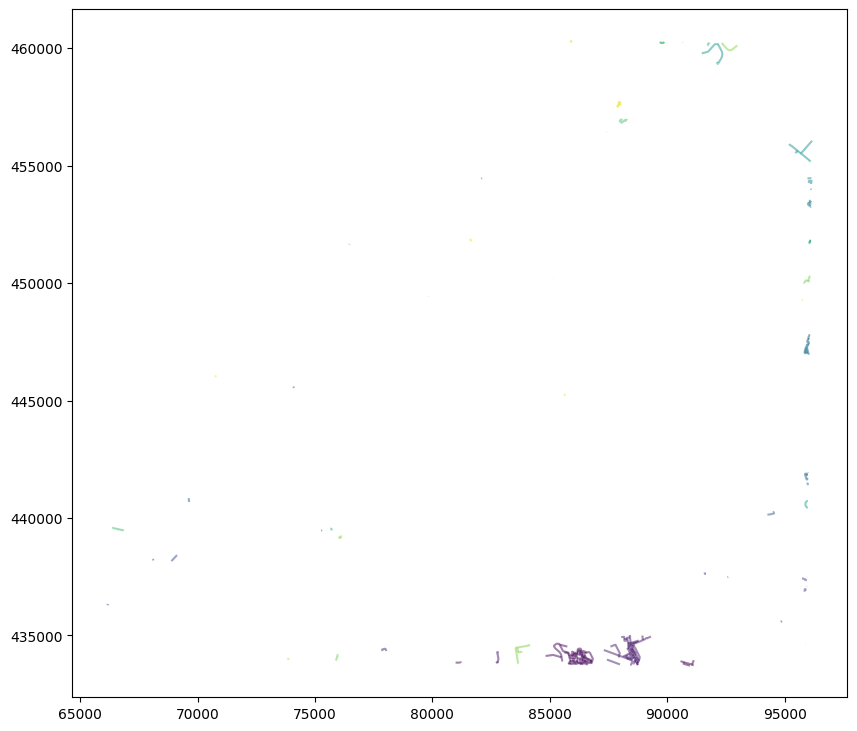

In [20]:

dissolved_roads[dissolved_roads['island_id']>0].plot(figsize=(10, 10), cmap='viridis', column='island_id', alpha=0.5)
plt.show()


In [39]:
remapped_assets.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

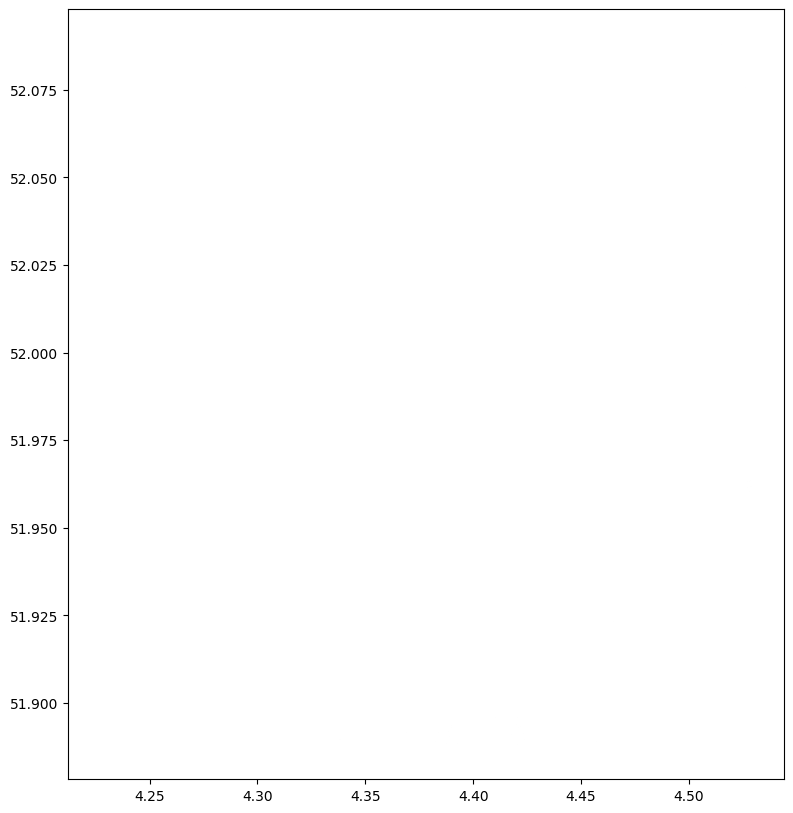

In [35]:
# from lonboard import viz
# Identify assets that are associated with islands other than island 0 and log them to attach them to a real island for disrupted steps

remapped_assets = temp_gdf_with_island_ids[temp_gdf_with_island_ids['island_id'] > 0].to_crs(epsg=4326)

#plot with matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
#use large markers
remapped_assets.plot(ax=plt.gca(), cmap='viridis', column='island_id', alpha=0.5, markersize=10000)
plt.show()


In [36]:
# Debug the data to see what's happening
print("Debugging remapped_assets:")
print(f"Original temp_gdf_with_island_ids shape: {temp_gdf_with_island_ids.shape}")
print(f"Unique island_ids: {temp_gdf_with_island_ids['island_id'].unique()}")
print(f"Island_id value counts:\n{temp_gdf_with_island_ids['island_id'].value_counts()}")

print(f"\nFiltered remapped_assets shape: {remapped_assets.shape}")
print(f"remapped_assets is empty: {remapped_assets.empty}")

# Check if there are any assets with island_id > 0
assets_with_islands = temp_gdf_with_island_ids[temp_gdf_with_island_ids['island_id'] > 0]
print(f"Number of assets with island_id > 0: {len(assets_with_islands)}")

Debugging remapped_assets:
Original temp_gdf_with_island_ids shape: (5041, 4)
Unique island_ids: [ 4  0  5  1  2 14 21 17 22 24 30 31]
Island_id value counts:
island_id
0     5007
5        9
2        9
21       4
24       4
22       2
4        1
1        1
14       1
17       1
30       1
31       1
Name: count, dtype: int64

Filtered remapped_assets shape: (34, 4)
remapped_assets is empty: False
Number of assets with island_id > 0: 34


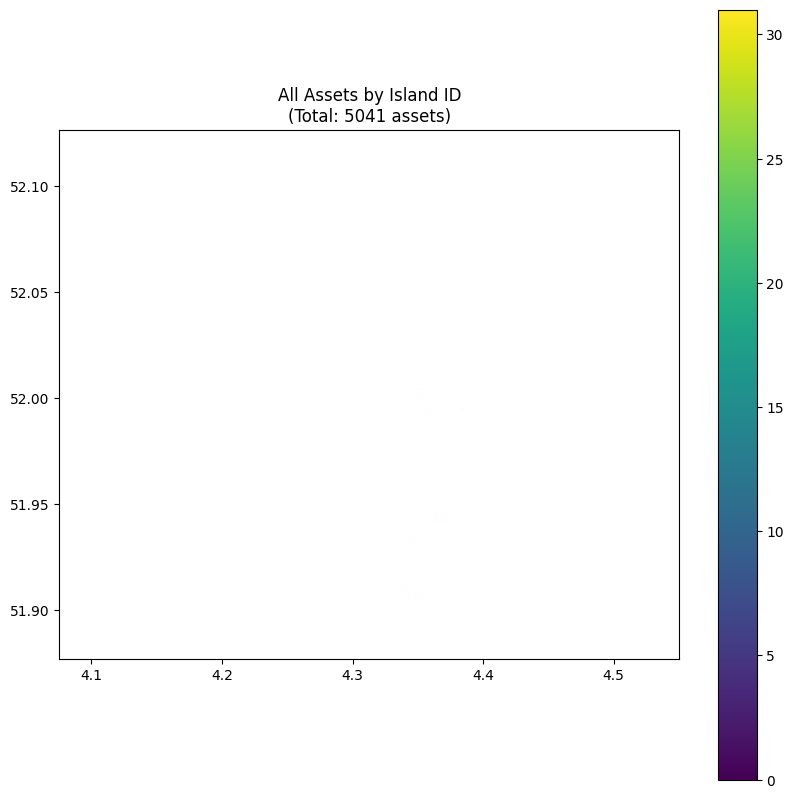

<Figure size 1000x1000 with 0 Axes>

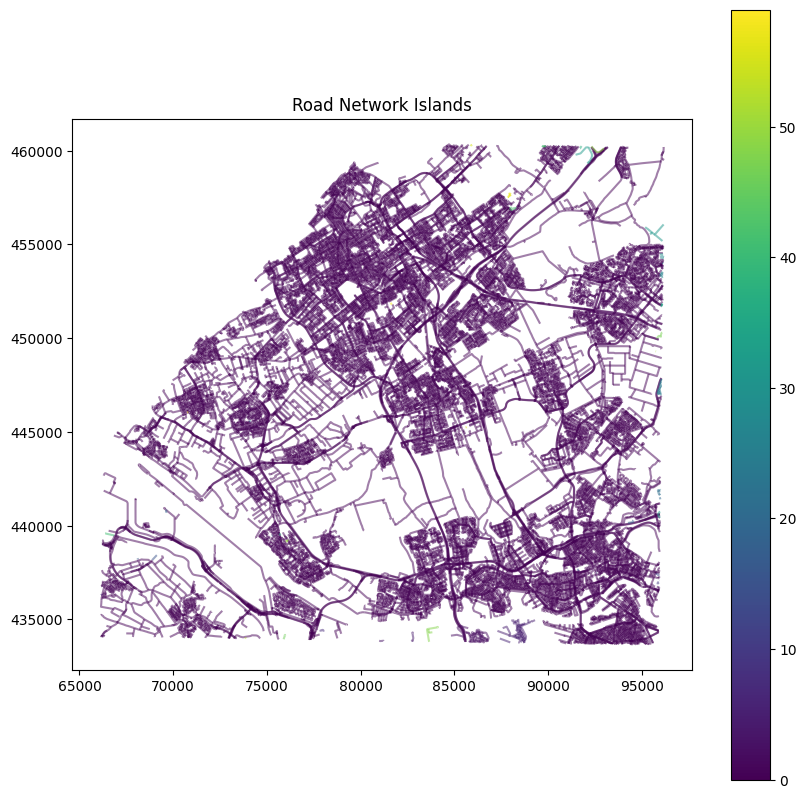

In [37]:
# Plot all assets colored by island_id (including island 0)
plt.figure(figsize=(10, 10))
temp_gdf_with_island_ids_wgs84 = temp_gdf_with_island_ids.to_crs(epsg=4326)
temp_gdf_with_island_ids_wgs84.plot(
    ax=plt.gca(), 
    column='island_id', 
    cmap='viridis', 
    alpha=0.7, 
    markersize=100,
    legend=True
)
plt.title(f"All Assets by Island ID\n(Total: {len(temp_gdf_with_island_ids_wgs84)} assets)")
plt.show()

# Also plot the road network islands to see the context
plt.figure(figsize=(10, 10))
dissolved_roads[dissolved_roads['island_id'] >= 0].plot(
    column='island_id', 
    cmap='viridis', 
    alpha=0.5, 
    figsize=(10, 10),
    legend=True
)
plt.title("Road Network Islands")
plt.show()

In [38]:
# Try with a higher threshold to create more islands
test_islands = match_island_ids_assets(temp_gdf, hazard_threshold=0.05, hazard_column='EV0_ma', config=_config)
(test_gdf_with_island_ids, test_dissolved_roads) = test_islands

print(f"With threshold 0.05:")
print(f"Unique island_ids: {sorted(test_gdf_with_island_ids['island_id'].unique())}")
print(f"Assets with island_id > 0: {len(test_gdf_with_island_ids[test_gdf_with_island_ids['island_id'] > 0])}")

Loading graph from: c:\repos\powerpath\raw_data\ZH_Delfland\static\output_graph\base_graph_hazard_editted.p
Using hazard_threshold=0.05, hazard_column=EV0_ma
Loaded 119005 island features
After deduplication: 59673 island features
Created 60 dissolved road islands
Successfully assigned 5041 assets to islands
With threshold 0.05:
Unique island_ids: [0, 1, 2, 4, 5, 14, 17, 21, 22, 24, 30, 31]
Assets with island_id > 0: 34


In [61]:
# (temp_gdf_with_island_ids, dissolved_roads)=baseline_islands

# if EV0 is in column name, find boundary islands (which exist even without hazard and cannot be addressed by the model)
# if 'EV0' in temp_gdf.columns:
if True:
    boundary_islands_osmids = dissolved_roads[dissolved_roads['island_id'] > 0]['osmid']
    boundary_assets = temp_gdf_with_island_ids[temp_gdf_with_island_ids['island_id'] > 0]

ignored_roads_test = dissolved_roads[dissolved_roads['osmid'].isin(boundary_islands_osmids)]
print(f"Number of ignored roads in test: {len(ignored_roads_test)}")
print(f'Number roads in dissolved roads initially: {len(dissolved_roads)}')

clean_dissolved_roads = dissolved_roads[~dissolved_roads['osmid'].isin(boundary_islands_osmids)]
print(f"Number of roads after removing boundary islands: {len(clean_dissolved_roads)}")

Number of ignored roads in test: 59
Number roads in dissolved roads initially: 60
Number of roads after removing boundary islands: 1


In [62]:
(EV1_temp_gdf_with_island_ids, EV1_dissolved_roads) = match_island_ids_assets(temp_gdf, hazard_threshold=0.2, hazard_column='EV1_ma', config=_config)
print(f'Total number of assets: {len(EV1_temp_gdf_with_island_ids)}')
print(f"Unique island_ids in EV1: {sorted(EV1_temp_gdf_with_island_ids['island_id'].unique())}")
print(f"Assets with island_id > 0: {len(EV1_temp_gdf_with_island_ids[EV1_temp_gdf_with_island_ids['island_id'] > 0])}")

Loading graph from: c:\repos\powerpath\raw_data\ZH_Delfland\static\output_graph\base_graph_hazard_editted.p
Using hazard_threshold=0.2, hazard_column=EV1_ma
Loaded 115404 island features
After deduplication: 57869 island features
Created 246 dissolved road islands
Successfully assigned 5041 assets to islands
Total number of assets: 5041
Unique island_ids in EV1: [0, 1, 2, 4, 5, 11, 14, 17, 18, 22, 24, 27, 28, 36, 37, 38, 46, 48, 56, 62, 63, 64, 65, 66, 68, 69, 71, 72, 73, 74, 77, 79, 81, 85, 89, 90, 92, 94, 99, 100, 105, 106, 109, 117, 121, 160, 163, 178]
Assets with island_id > 0: 121


In [63]:
#cleaning 

EV1_clean_dissolved_roads = EV1_dissolved_roads[~EV1_dissolved_roads['osmid'].isin(boundary_islands_osmids)]
print(f"Number of roads after removing boundary islands in EV1: {len(EV1_clean_dissolved_roads)}")
print(f'Number of road islands removed in EV1: {len(EV1_dissolved_roads) - len(EV1_clean_dissolved_roads)}')

Number of roads after removing boundary islands in EV1: 188
Number of road islands removed in EV1: 58


In [66]:
boundary_assets

,Laagspa_ID,geometry,type,island_id
0,None,"POLYGON ((82786.867 433964.643, 82788.543 4339...",ls,4
325,None,"POLYGON ((88458.869 433739.231, 88459.807 4337...",ls,5
326,None,"POLYGON ((88272.414 434037.638, 88271.937 4340...",ls,5
327,None,"POLYGON ((88426.805 434380.606, 88427.698 4343...",ls,5
328,None,"POLYGON ((88473.359 434575.165, 88472.938 4345...",ls,5
329,None,"POLYGON ((87771.172 434610.602, 87772.137 4346...",ls,5
330,None,"POLYGON ((88689.009 433892.466, 88688.726 4338...",ls,5
331,None,"POLYGON ((88641.567 434087.054, 88642.456 4340...",ls,5
332,None,"POLYGON ((88489.129 434281.515, 88489.599 4342...",ls,5
333,None,"POLYGON ((88558.957 434308.133, 88558.052 4343...",ls,5


In [67]:
EV1_clean_gdf_assets = EV1_temp_gdf_with_island_ids[~EV1_temp_gdf_with_island_ids.index.isin(boundary_assets.index)]
print(f"Number of assets after removing boundary islands in EV1: {len(EV1_clean_gdf_assets)}")
print(f'Number of asset islands removed in EV1: {len(EV1_temp_gdf_with_island_ids) - len(EV1_clean_gdf_assets)}')


Number of assets after removing boundary islands in EV1: 5007
Number of asset islands removed in EV1: 34


In [56]:
dissolved_roads.head()

,island_id,geometry,osmid,lanes,name,highway,maxspeed,oneway,reversed,length,...,EV8_ma,EV9_ma,length_m,width,ref,junction,access,service,est_width,island_size_km
0,0,"MULTILINESTRING ((85777.038 447150.231, 85657....",48688450,2,Delfgauwseweg,tertiary,50,False,True,141.357960,...,0.0,0.0,141.357960,7,S100,roundabout,private,driveway,1.5,11730.283057
1,1,"MULTILINESTRING ((91057.508 433759.197, 91084....","[496263308, 7516790]",2,Nijmegenstraat,unclassified,50,False,True,82.853786,...,0.0,0.0,82.853786,None,None,None,None,None,None,2.287699
2,2,"MULTILINESTRING ((86117.283 433763.716, 86114....",7548943,2,Vroomstraat,residential,30,False,True,35.822577,...,0.0,0.0,35.822577,None,None,None,None,None,None,26.496522
3,3,"LINESTRING (81233.020 433842.410, 81228.872 43...",1305249478,2,Oude Maasweg,unclassified,80,False,False,251.623865,...,0.0,0.0,251.623865,None,None,None,None,None,None,0.503248
4,4,"MULTILINESTRING ((82769.502 434248.502, 82771....","[7552494, 1339466591]",None,Tankweg,unclassified,80,False,True,399.718745,...,0.0,0.0,399.718745,None,None,None,None,None,None,1.191095


<Axes: >

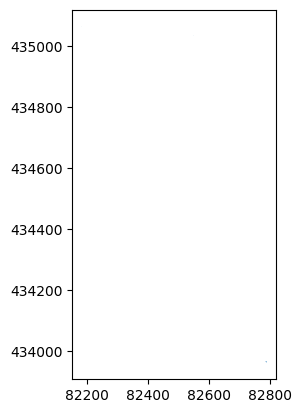

In [55]:
test_gdf_with_island_ids.head()

#plot the first element with very large dots
test_gdf_with_island_ids.head(3).plot(markersize=10)

OLD CODE

In [15]:
# load road network, find bounding box, and clip electricity stations to the bounding box
road_network_path = repo_path.parent / 'data' / 'static' / 'network' / 'try_study_area_larger.shp'
road_network = gpd.read_file(road_network_path)
bounding_box = road_network.union_all().envelope   
print(type(bounding_box)) 

AttributeError: 'GeoDataFrame' object has no attribute 'union_all'

In [27]:
road_network.explore()

In [28]:
# load the shapefiles and clip to the bounding box
ls_stations = gpd.read_file(ls_station_path/'Laagspanningsstations.shp')
ls_stations = ls_stations.to_crs(road_network.crs)  # Ensure CRS matches
ls_stations = ls_stations.clip(bounding_box)
msls_stations = gpd.read_file(msls_station_path/'MiddenLaagspanningsstations.shp')
msls_stations = msls_stations.to_crs(road_network.crs)
msls_stations = msls_stations.clip(bounding_box)
ms_stations = gpd.read_file(ms_station_path/'Middenspanningsstations.shp')
ms_stations = ms_stations.to_crs(road_network.crs)  # Ensure CRS matches
ms_stations = ms_stations.clip(bounding_box)

In [29]:
# save to repo data folder
ls_stations.to_file(data_path/'electricity'/'ls_stations_clipped.shp')
msls_stations.to_file(data_path/'electricity'/'msls_stations_clipped.shp')
ms_stations.to_file(data_path/'electricity'/'ms_stations_clipped.shp')

In [30]:
# load the power lines too
ls_lines = gpd.read_file(ls_lines_path/'Laagspanningsverbindingen.shp')
ls_lines = ls_lines.to_crs(road_network.crs)  # Ensure CRS matches
ms_lines = gpd.read_file(ms_lines_path/'Middenspanningsverbindingen.shp')
ms_lines = ms_lines.to_crs(road_network.crs)  # Ensure CRS matches


In [31]:
# for the power lines, create a buffered bounding box with a 15% area in each direction
# find the width and height of the bounding box
minx, miny, maxx, maxy = bounding_box.bounds
bbox_width = maxx - minx
bbox_height = maxy - miny
# calculate the buffer size as 15% of the width and height
buffer_size_x = bbox_width * 0.15
buffer_size_y = bbox_height * 0.15
# pick the largest of the two buffer sizes
buffer_size = max(buffer_size_x, buffer_size_y)
# create a buffered bounding box
buffered_bounding_box = bounding_box.buffer(buffer_size)
# clip the power lines to the buffered bounding box
ls_lines = ls_lines.clip(buffered_bounding_box)
ms_lines = ms_lines.clip(buffered_bounding_box)

In [32]:
# ms_lines.explore()

In [33]:
# save the clipped power lines to the repo data folder
ls_lines.to_file(data_path/'electricity'/'ls_lines_clipped.shp')
ms_lines.to_file(data_path/'electricity'/'ms_lines_clipped.shp')

In [7]:


with rio_open(hazard_map_path) as src:
    hazard_map = src.read(1)
    hazard_transform = src.transform
    hazard_crs = src.crs
    
    # Reproject bounding_box to hazard_crs using GeoSeries
    bounding_box_gs = gpd.GeoSeries([bounding_box], crs=road_network.crs)
    bounding_box_haz_crs = bounding_box_gs.to_crs(hazard_crs).iloc[0]
    hazard_map_clipped, hazard_transform_clipped = mask(src, [bounding_box_haz_crs], crop=True)

# plot the hazard map
plt.figure(figsize=(10, 10))
plt.imshow(hazard_map_clipped[0], cmap='Blues', vmin=0) # no data values are large negatives, so adjust the colormap 
plt.colorbar(label='Pixel Values')  
plt.title('Hazard Map')
plt.show()


NameError: name 'bounding_box' is not defined

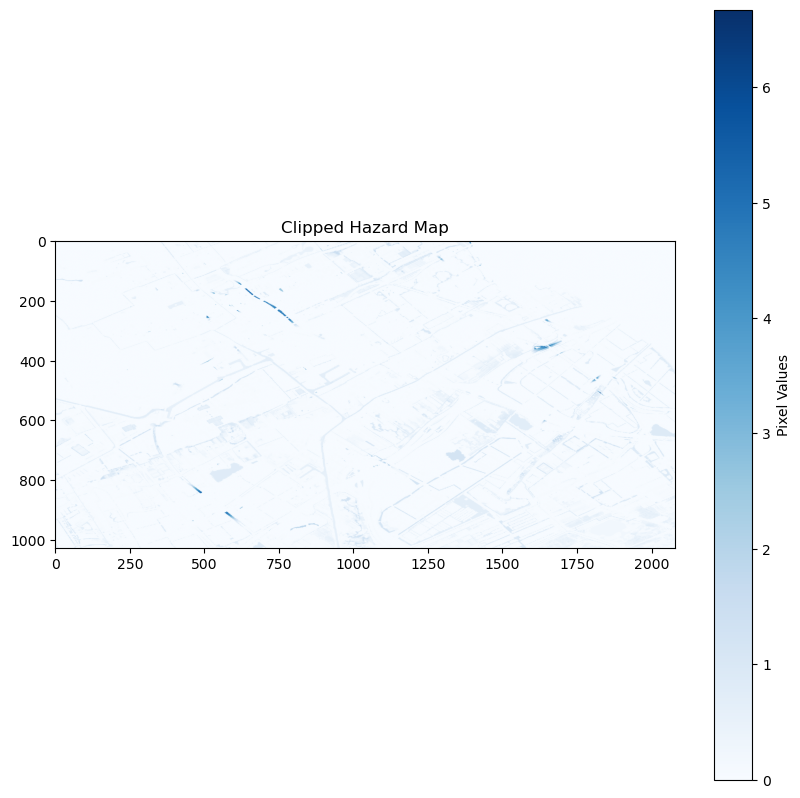

In [35]:
# save the clipped hazard map
clipped_hazard_map_path = data_path / 'static' / 'hazard' / 'processed' / 'clipped_hazard_map_larger.tif'
with rio_open(clipped_hazard_map_path, 'w', driver='GTiff',
             height=hazard_map_clipped.shape[1], width=hazard_map_clipped.shape[2],
             count=1, dtype=hazard_map_clipped.dtype,
             crs=hazard_crs, transform=hazard_transform_clipped) as dst:
    dst.write(hazard_map_clipped[0], 1)

# load the clipped hazard map
clipped_hazard_map = rio_open(clipped_hazard_map_path)
# plot the clipped hazard map
plt.figure(figsize=(10, 10))
plt.imshow(clipped_hazard_map.read(1), cmap='Blues', vmin=0)  # Change the colormap if desired
plt.colorbar(label='Pixel Values')
plt.title('Clipped Hazard Map')
plt.show()

In [36]:
# Create artificial timestep maps where day 0 is half the intensity of the basline map, day 1 is the baseline map, and day 2 is half the intensity of the baseline map, day 3-7 is no flooding
timesteps = range(8)  # 0 to 7 inclusive
timestep_maps = {}
for timestep in timesteps:
    if timestep == 0:
        timestep_maps[timestep] = clipped_hazard_map.read(1) * 0.5  # Half intensity
    elif timestep == 1:
        timestep_maps[timestep] = clipped_hazard_map.read(1)  # Baseline
    elif timestep == 2:
        timestep_maps[timestep] = clipped_hazard_map.read(1) * 0.5  # Half intensity
    else:
        timestep_maps[timestep] = clipped_hazard_map.read(1) * 0  # No flooding


In [10]:
# save the timestep maps
# timestep_map_dir = data_path / 'static' / 'hazard' / 'processed' / 'timesteps'
timestep_maps = {}

timestep_map_dir = Path(r'N:\Projects\11209000\11209175\B. Measurements and calculations\Data\timeseries_data\reprojected')
map_name='20220610 JF  Limburgbui 200 mm 48h  voormalen 15 cm  GHG_waterschijf_1900-01-03_scale_5_wgs84.tif'

new_file_names = ['0_blank_map.tif', 'z1_blank_map.tif', 'z2_blank_map.tif', 'z3_blank_map.tif']

hm = rio_open(timestep_map_dir / map_name)

dict_idx_name = {i:new_file_names[i] for i in range(len(new_file_names))}

for timestep in range(len(new_file_names)):
    timestep_maps[timestep] = hm.read(1) * 0
    
for idx, file_name in dict_idx_name.items():
    with rio_open(timestep_map_dir / file_name, 'w', driver='GTiff',
                    height=hm.height, width=hm.width,
                    count=1, dtype=hm.dtypes[0],
                    crs=hm.crs, transform=hm.transform) as dst:
        dst.write(timestep_maps[idx], 1)

In [ ]:

for timestep, map_data in timestep_maps.items():
    if timestep < 10:
        filename = f"clipped_hazard_map_0{timestep}.tif"
    else:
        filename = f"clipped_hazard_map_{timestep}.tif"
    filepath = timestep_map_dir / filename
    with rio_open(filepath, 'w', driver='GTiff',
                 height=map_data.shape[0], width=map_data.shape[1],
                 count=1, dtype=map_data.dtype,
                 crs=clipped_hazard_map.crs, transform=clipped_hazard_map.transform) as dst:
        dst.write(map_data, 1)